# this notebook compares the tcrbridge scores of the TCR-pMHC of the cognate epitope versus all other  (swapped) epitopes of the non-validating TCRs 

figure S4

In [ ]:
import json
import pandas as pd
import os
import numpy as np
import random
from pathlib import Path
import sys 
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns

In [ ]:
from matplotlib import rcParams
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.font_manager as fm 

def set_mpl_params(mpl):
    mylines = 0.75 # pt updated
    mpl.rcParams['axes.linewidth'] = mylines # default 1
    mpl.rcParams['ytick.direction'] = 'out' # default 'in'
    mpl.rcParams['xtick.direction'] = 'out' # default 'in'
    mpl.rcParams['xtick.major.size'] = 3.5 # default 4
    mpl.rcParams['ytick.major.size'] = 3.5 # default 4
    mpl.rcParams['xtick.major.width'] = mylines # default 0.5
    mpl.rcParams['ytick.major.width'] = mylines # default 0.5
    mpl.rcParams['grid.linewidth'] = mylines/1.5# default 0.5
    mpl.rcParams['grid.color'] = '0.8' # default 'k'
    mpl.rcParams['grid.linestyle'] = 'solid'# default ':'
    mpl.rcParams['legend.frameon'] = False # default True
    mpl.rcParams['font.family'] = 'Arial' # added
    mpl.rcParams['figure.dpi']= 300
    mpl.rc("savefig", dpi=300)
    mpl.rcParams['pdf.fonttype'] = 42 # embed fonts as editable text in illustrator
    mpl.rcParams['ps.fonttype'] = 42 # embed fonts as editable text in illustrator
    mpl.rcParams['figure.autolayout'] = True  # set tight layout to always true
    mpl.rcParams['xtick.labelsize'] = 7  # X-axis tick labels
    mpl.rcParams['ytick.labelsize'] = 7  # Y-axis tick labels

    return mpl, mylines


out_path = ''
SAVE_FIGS = True
fm.fontManager.addfont("/Library/Fonts/Arial Unicode.ttf") 
mpl, mylines = set_mpl_params(mpl)
figsize = (6/2.54, 5/2.54)
figsize_prc_auc = (5/2.54, 4/2.54)
swap_plot_size = (4/2.54, 4/2.54)
dotsize = 12
fontsize_axes = 7
background_alpha = 0.45
color_alpha = 0.6
linewidth = 1.0

In [ ]:
labels_df = pd.read_json( 'experiment_set_stats_all-v-1.json')
ref_df = pd.read_csv('ref_df_subset_on_fasta_3693.csv')

In [ ]:
neg_ylq = labels_df['YLQPRTFLL'].T['neg_ids']
neg_glc = labels_df['GLCTLVAML'].T['neg_ids']

In [ ]:
# glc tcrs with glc epitope
glc_cog = pd.read_csv('glctlvaml_all_glc_vdjdb-ylq-glc-screen_structure_df.csv')
glc_cog['tcr_cog'] = 'GLCTLVAML'
glc_cog['epitope_cog'] = 'GLCTLVAML'

ylq_epi_glc_tcr_pos = pd.read_csv('ylqprtfll_swap_glc-tcr_ylq-pep_vdjdb-ylq-glc-screen_structure_df.csv')
ylq_epi_glc_tcr_pos['tcr_cog'] = 'GLCTLVAML'
ylq_epi_glc_tcr_pos['epitope_cog'] = 'YLQPRTFLL'

ylq_epi_glc_tcr_neg = pd.read_csv('ylqprtfll_swap-neg_glc-tcr_ylq-pep_vdjdb-ylq-glc-screen_structure_df.csv')
ylq_epi_glc_tcr_neg['tcr_cog'] = 'GLCTLVAML'
ylq_epi_glc_tcr_neg['epitope_cog'] = 'YLQPRTFLL'

glc_swapped = pd.concat([ylq_epi_glc_tcr_pos, ylq_epi_glc_tcr_neg], axis=0)



ylq_cog = pd.read_csv('ylqprtfll_all_ylq_vdjdb-ylq-glc-screen_structure_df.csv')
ylq_cog['tcr_cog'] = 'YLQPRTFLL'
ylq_cog['epitope_cog'] = 'YLQPRTFLL'
glc_epi_ylq_tcr_pos = pd.read_csv('glctlvaml_swap_ylq-tcr_glc-pep_vdjdb-ylq-glc-screen_structure_df.csv')
glc_epi_ylq_tcr_pos['tcr_cog'] = 'YLQPRTFLL'
glc_epi_ylq_tcr_pos['epitope_cog'] = 'GLCTLVAML'

glc_epi_ylq_tcr_neg = pd.read_csv('glctlvaml_swap-neg_ylq-tcr_glc-pep_vdjdb-ylq-glc-screen_structure_df.csv')
glc_epi_ylq_tcr_neg['tcr_cog'] = 'YLQPRTFLL'
glc_epi_ylq_tcr_neg['epitope_cog'] = 'GLCTLVAML'
ylq_swapped = pd.concat([glc_epi_ylq_tcr_pos, glc_epi_ylq_tcr_neg], axis=0)


for df in [ylq_cog, ylq_swapped, glc_cog, glc_swapped]:
    df['AC_ABi'] = df['AC_ABi'].fillna(0)
    df['BC_ABi'] = df['BC_ABi'].fillna(0)
    df['tcrbridge'] = (df['AC_ABi'] + df['BC_ABi']) /2


In [ ]:
ylq_cog['tcr_id_original'] = ylq_cog['tcr_id'].str.split('_YLQPRTFLL').str[0] + '_YLQPRTFLL'
ylq_swapped['tcr_id_original'] = ylq_swapped['tcr_id'].str.split('_YLQPRTFLL').str[0] + '_YLQPRTFLL'

glc_cog['tcr_id_original'] = glc_cog['tcr_id'].str.split('_GLCTLVAML').str[0] + '_GLCTLVAML'
glc_swapped['tcr_id_original'] = glc_swapped['tcr_id'].str.split('_GLCTLVAML').str[0] + '_GLCTLVAML'

ylq = pd.merge(ylq_cog[['tcr_id_original', 'tcrbridge']], ylq_swapped[['tcr_id_original', 'tcrbridge']], on='tcr_id_original', suffixes=('_cog', '_swapped'))
ylq['tcrbridge_ylq'] = ylq['tcrbridge_cog']
ylq['tcrbridge_glc'] = ylq['tcrbridge_swapped']
glc = pd.merge(glc_cog[['tcr_id_original', 'tcrbridge']], glc_swapped[['tcr_id_original', 'tcrbridge']], on='tcr_id_original', suffixes=('_cog', '_swapped'))
glc['tcrbridge_ylq'] = glc['tcrbridge_swapped']
glc['tcrbridge_glc'] = glc['tcrbridge_cog']

In [ ]:
ylq_pos = ylq[ylq['tcr_id_original'].isin(labels_df['YLQPRTFLL'].T['pos_ids'])].copy()
ylq_pos['label_ylq'] = True
ylq_pos['label_glc'] = False
ylq_neg = ylq[ylq['tcr_id_original'].isin(labels_df['YLQPRTFLL'].T['neg_ids'])].copy()
ylq_neg['label_ylq'] = False
ylq_neg['label_glc'] = False  
ylq_posneg = pd.concat([ylq_pos, ylq_neg], axis=0)

glc_pos = glc[glc['tcr_id_original'].isin(labels_df['GLCTLVAML'].T['pos_ids'])].copy()
glc_pos['label_glc'] = True
glc_pos['label_ylq'] = False
glc_neg = glc[glc['tcr_id_original'].isin(labels_df['GLCTLVAML'].T['neg_ids'])].copy()
glc_neg['label_glc'] = False
glc_neg['label_ylq'] = False
glc_posneg = pd.concat([glc_pos, glc_neg], axis=0)

all_df = pd.concat([ylq_posneg, glc_posneg], axis=0)

all_df['orig_epi_annotation'] = all_df['tcr_id_original'].str.split('_').str[-1]


158 all df ylq_only
cornflowerblue    158
Name: color, dtype: int64


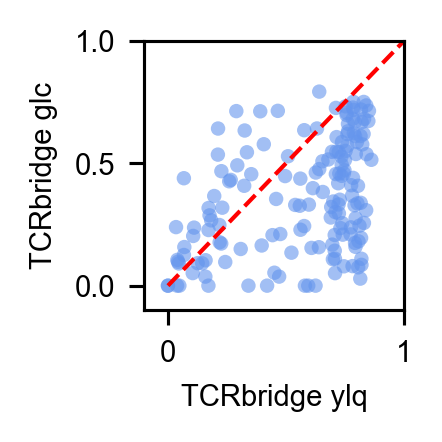

109 all df glc_only
indianred    109
Name: color, dtype: int64


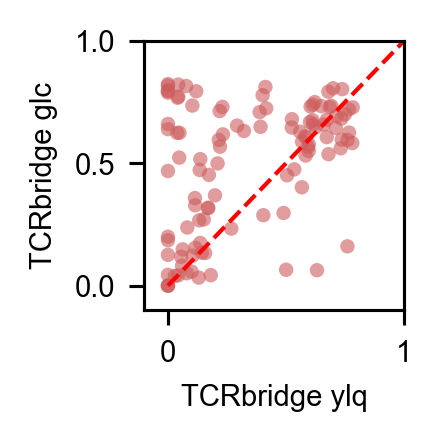

551 all df all
black             284
cornflowerblue    158
indianred         109
Name: color, dtype: int64


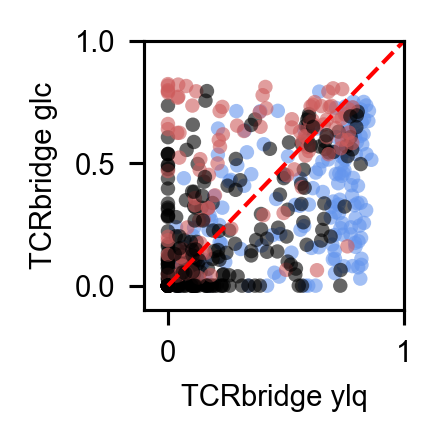

267 all df no_black
cornflowerblue    158
indianred         109
Name: color, dtype: int64


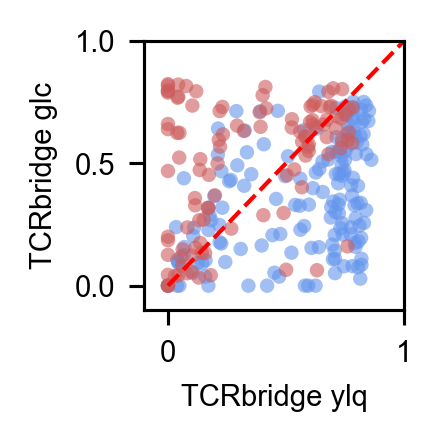

284 all df neg_only_color_by_epitope
cornflowerblue    225
indianred          59
Name: color, dtype: int64


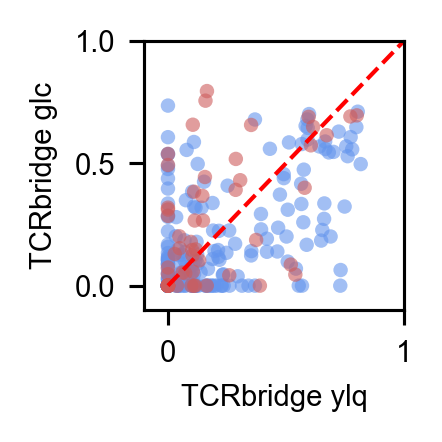

551 all df all_with_epi_colors
cornflowerblue    383
indianred         168
Name: color, dtype: int64


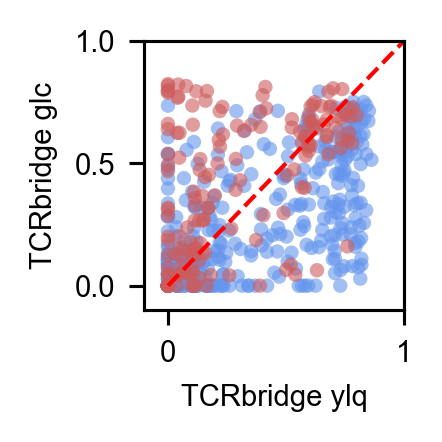

551 all df pos_only
black             284
cornflowerblue    158
indianred         109
Name: color, dtype: int64


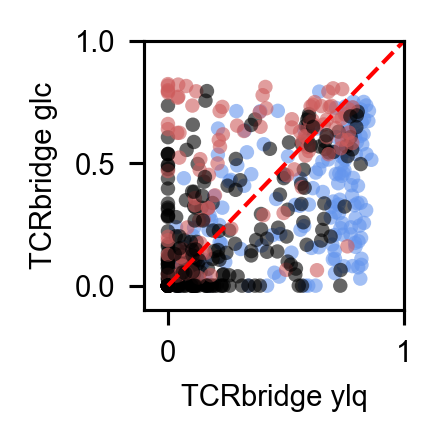

In [153]:
all_df_orig = all_df.copy()
for plot_type in ['ylq_only', 'glc_only', 'all', 'no_black', 'neg_only_color_by_epitope','all_with_epi_colors', 'pos_only']:
    all_df = all_df_orig.copy()
    # if label_ylq, color cornflowerblue, if label_glc, color indianred if neither color black
    all_df['color'] = 'black'
    all_df.loc[all_df['label_ylq'], 'color'] = 'cornflowerblue'
    all_df.loc[all_df['label_glc'], 'color'] = 'indianred'
 
    if plot_type == 'ylq_only':
        all_df = all_df[all_df['color'] == 'cornflowerblue']
    elif plot_type == 'glc_only':
        all_df = all_df[all_df['color'] == 'indianred']
    elif plot_type == 'no_black':
        all_df = all_df[all_df['color'] != 'black']
    elif plot_type == 'neg_only_color_by_epitope':
        all_df =  all_df[all_df['color'] == 'black']
        all_df.loc[all_df['orig_epi_annotation'] == 'YLQPRTFLL', 'color'] = 'cornflowerblue'
        all_df.loc[all_df['orig_epi_annotation'] == 'GLCTLVAML', 'color'] = 'indianred'
    elif plot_type == 'all_with_epi_colors':
        all_df.loc[all_df['orig_epi_annotation'] == 'YLQPRTFLL', 'color'] = 'cornflowerblue'
        all_df.loc[all_df['orig_epi_annotation'] == 'GLCTLVAML', 'color'] = 'indianred'


    print(len(all_df), 'all df', plot_type)
    print(all_df['color'].value_counts())



    plt.figure(figsize=swap_plot_size)
    plt.scatter(all_df['tcrbridge_ylq'], all_df['tcrbridge_glc'], alpha=0.6, edgecolors='None', c=all_df['color'], s=dotsize)
    plt.xlabel("TCRbridge ylq", fontsize=fontsize_axes)
    plt.ylabel("TCRbridge glc", fontsize=fontsize_axes)
    plt.xlim(-0.1, 1)
    plt.ylim(-0.1, 1)
    plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='(y=x)', linewidth=linewidth)

    if SAVE_FIGS:
        plt.savefig(os.path.join(out_path, f'swap_tcrbridge_{plot_type}.pdf'))
    plt.show()
    plt.close()

267 all df
-0.2364960240357364 mean closeness
-0.16170085089093716 mean closeness
Average precision-recall score: 0.739, random: 0.408


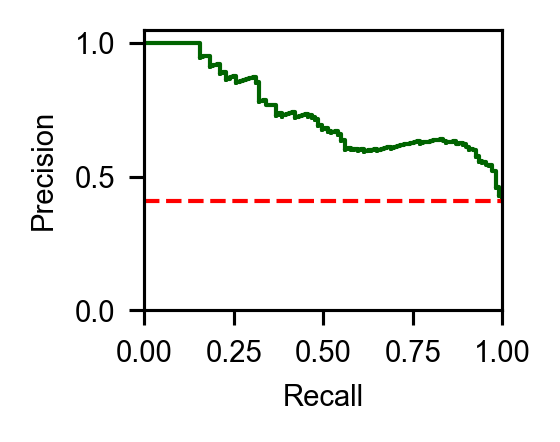

roc_auc 0.804


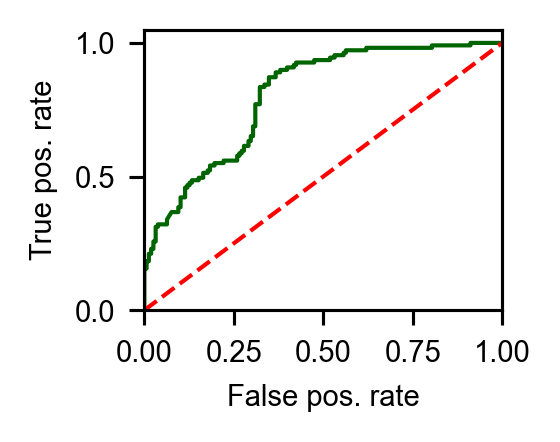

Average precision-recall score: 0.823, random: 0.592


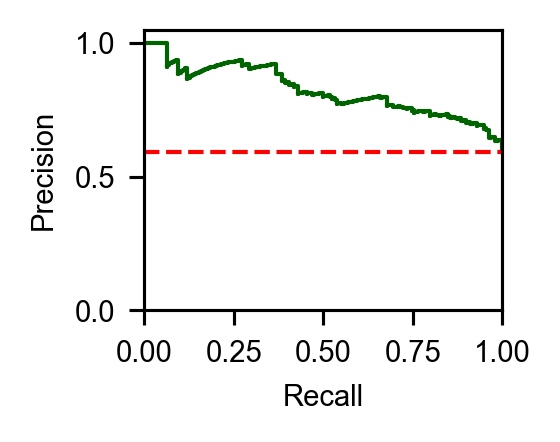

roc_auc 0.775


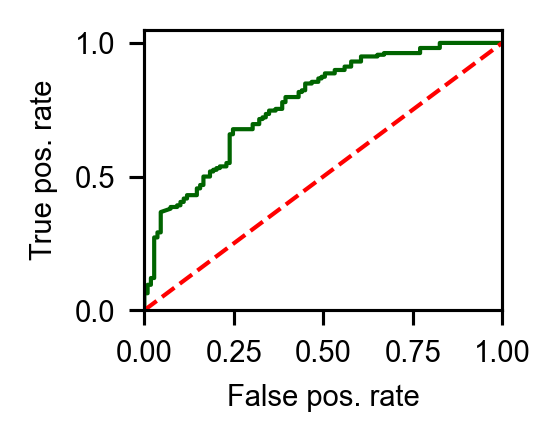

284 all df
-0.08726931028317188 mean closeness
-0.07344431117789715 mean closeness
Average precision-recall score: 0.254, random: 0.208


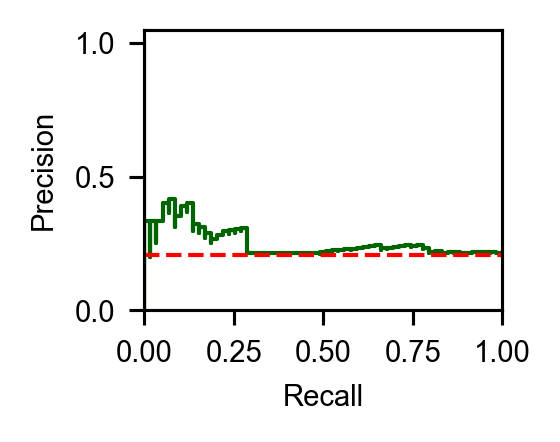

roc_auc 0.561


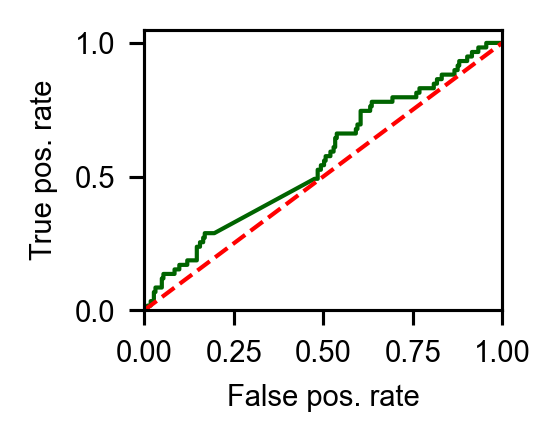

Average precision-recall score: 0.842, random: 0.792


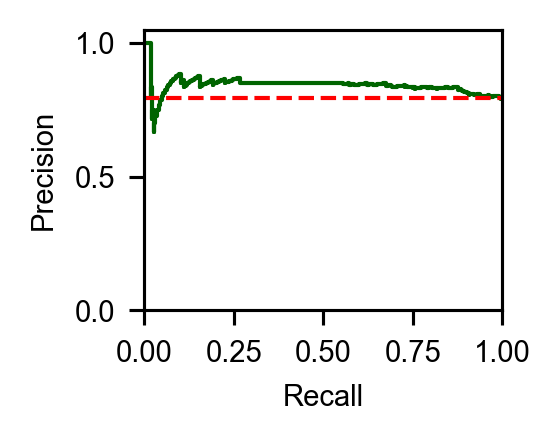

roc_auc 0.621


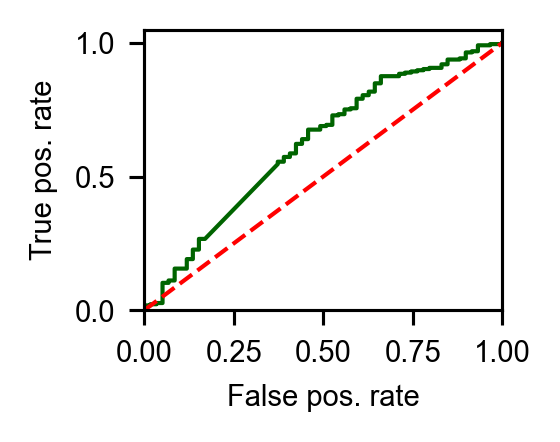

In [ ]:
import numpy as np
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve


for plot_type in ['all_data', 'neg_only']:
    all_df = all_df_orig.copy()
    all_df['color'] = 'black'
    all_df.loc[all_df['label_ylq'], 'color'] = 'cornflowerblue'
    all_df.loc[all_df['label_glc'], 'color'] = 'indianred'

    if plot_type == 'all_data':
        all_df = all_df[all_df['color'] != 'black']
        label_ylq = all_df['label_ylq'].values
        label_glc = all_df['label_glc'].values
    elif plot_type == 'neg_only':
        all_df =  all_df[all_df['color'] == 'black']
        label_ylq = [True if epi == 'YLQPRTFLL' else False for epi in all_df['orig_epi_annotation']]
        label_glc = [True if epi == 'GLCTLVAML' else False for epi in all_df['orig_epi_annotation']]
    print(len(all_df), 'all df')


    closeness_glc_id_all = list(all_df['tcr_id_original'])
    closeness_ylq_id_all = list(all_df['tcr_id_original'])

    x = np.array(all_df['tcrbridge_ylq'])
    y = np.array(all_df['tcrbridge_glc'])
    points = np.stack([x, y], axis=1)  # Stack x and y into (N, 2) shape


    v_glc = np.array([-1, 1/2])
    v_glc = v_glc / np.linalg.norm(v_glc)  # unit vector
    closeness_glc_all = points @ v_glc  # shape (N,)

    v_ylq = np.array([1/2, -1])
    v_ylq = v_ylq / np.linalg.norm(v_ylq)  # unit vector
    closeness_ylq_all = points @ v_ylq  # shape (N,)

    print(np.mean(closeness_glc_all), 'mean closeness')
    print(np.mean(closeness_ylq_all), 'mean closeness')

    precision_glc, recall_glc, _ = precision_recall_curve(label_glc, closeness_glc_all)
    average_precision_glc = average_precision_score(label_glc, closeness_glc_all)
    random_glc = sum(label_glc) / len(label_glc)
    print(f'Average precision-recall score: {average_precision_glc:.3f}, random: {random_glc:.3f}')
    plt.figure(figsize=figsize_prc_auc) 
    plt.step(recall_glc, precision_glc, alpha=1, where='post', label=f'tcrbridge ({average_precision_glc:.2f} AP)', color='darkgreen', linewidth=linewidth)
    plt.axhline(y=random_glc, color='r', linestyle='--', label=f'Random ({random_glc:.2f} AP)',linewidth=linewidth)

    plt.xlabel('Recall', fontsize=fontsize_axes)
    plt.ylabel('Precision', fontsize=fontsize_axes)
    plt.ylim(0, 1.05)
    plt.xlim(0, 1.0)
    if SAVE_FIGS:
        plt.savefig(out_path + f'prc_{average_precision_glc:.2f}_glc-swap_alignment_{plot_type}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # auc for glc
    roc_auc_glc = roc_auc_score(label_glc, closeness_glc_all)
    print(f'roc_auc {roc_auc_glc:.3f}')
    fpr_glc, tpr_glc, _ = roc_curve(label_glc, closeness_glc_all)
    plt.figure(figsize=figsize_prc_auc)
    plt.plot(fpr_glc, tpr_glc, alpha=1, label=f'tcrbridge ({roc_auc_glc:.2f} AUC)', color='darkgreen', linewidth=linewidth)
    plt.plot([0, 1], [0, 1], color='r', linestyle='--', label=f'Random (0.50 AUC)', linewidth=linewidth)
    plt.xlabel('False pos. rate', fontsize=fontsize_axes)
    plt.ylabel('True pos. rate', fontsize=fontsize_axes)
    plt.ylim(0, 1.05)
    plt.xlim(0, 1.0)
    if SAVE_FIGS:
        plt.savefig(out_path + f'auc_{roc_auc_glc:.2f}_glc-swap_alignment_{plot_type}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


    precision_ylq, recall_ylq, _ = precision_recall_curve(label_ylq, closeness_ylq_all)
    average_precision_ylq = average_precision_score(label_ylq, closeness_ylq_all)
    random_ylq = sum(label_ylq) / len(label_ylq)
    print(f'Average precision-recall score: {average_precision_ylq:.3f}, random: {random_ylq:.3f}')
    plt.figure(figsize=figsize_prc_auc)
    plt.step(recall_ylq, precision_ylq, alpha=1, where='post', label=f'tcrbridge ({average_precision_ylq:.2f} AP)', color='darkgreen', linewidth=linewidth)
    plt.axhline(y=random_ylq, color='r', linestyle='--', label=f'Random ({random_ylq:.2f} AP)', linewidth=linewidth)
    plt.xlabel('Recall', fontsize=fontsize_axes)
    plt.ylabel('Precision', fontsize=fontsize_axes)
    plt.ylim(0, 1.05)
    plt.xlim(0, 1.0)
    if SAVE_FIGS:
        plt.savefig(out_path + f'prc_{average_precision_ylq:.2f}_ylq-swap_alignment_{plot_type}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    roc_auc_ylq = roc_auc_score(label_ylq, closeness_ylq_all)
    print(f'roc_auc {roc_auc_ylq:.3f}')
    fpr_ylq, tpr_ylq, _ = roc_curve(label_ylq, closeness_ylq_all)
    plt.figure(figsize=figsize_prc_auc)
    plt.plot(fpr_ylq, tpr_ylq, alpha=1, label=f'tcrbridge ({roc_auc_ylq:.2f} AUC)', color='darkgreen', linewidth=linewidth)
    plt.plot([0, 1], [0, 1], color='r', linestyle='--', label=f'Random (0.50 AUC)', linewidth=linewidth)
    plt.xlabel('False pos. rate', fontsize=fontsize_axes)
    plt.ylabel('True pos. rate', fontsize=fontsize_axes)
    plt.ylim(0, 1.05)
    plt.xlim(0, 1.0)
    if SAVE_FIGS:
        plt.savefig(out_path + f'auc_{roc_auc_ylq:.2f}_ylq-swap_alignment_{plot_type}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
